In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import sys , os

In [3]:
sys.path.append(os.path.join(os.getcwd(),'..','src'))
print("imported succesfully")

imported succesfully


In [5]:
data_path = os.path.join('..','Data','raw')

datasets = {
    'adult_income' : pd.read_csv(os.path.join(data_path , 'adult_income.csv')),
    'breast_cancer' : pd.read_csv(os.path.join(data_path , 'breast_cancer.csv')),
    'credit_fraud' : pd.read_csv(os.path.join(data_path , 'credit_fraud.csv')),
    'diabetes' : pd.read_csv(os.path.join(data_path , 'diabetes.csv')),
    'heart_disease' : pd.read_csv(os.path.join(data_path , 'heart_disease.csv')),
    'stroke' : pd.read_csv(os.path.join(data_path , 'stroke.csv'))
} 
for name , df in datasets.items():
    print(f"{name} : {df.shape}")

adult_income : (32561, 15)
breast_cancer : (569, 33)
credit_fraud : (284807, 31)
diabetes : (768, 9)
heart_disease : (1025, 14)
stroke : (5110, 12)


In [12]:
for name , df in datasets.items():
    print(f"DATASETS :{name.upper()}")
    
    print(" --- "*15)
    
    print(f"shape : {df.shape}")
    
    print(" --- "*15)
    
    print(f"column datatypes : {df.dtypes}")
    
    print(" --- "*15)
    print()
    print(f"missing values : {df.isnull().sum()[df.isnull().sum() > 0]}")
    print(" === "*20)
    print(" === "*20)
    print()

DATASETS :ADULT_INCOME
 ---  ---  ---  ---  ---  ---  ---  ---  ---  ---  ---  ---  ---  ---  --- 
shape : (32561, 15)
 ---  ---  ---  ---  ---  ---  ---  ---  ---  ---  ---  ---  ---  ---  --- 
column datatypes : age                int64
workclass         object
fnlwgt             int64
education         object
education.num      int64
marital.status    object
occupation        object
relationship      object
race              object
sex               object
capital.gain       int64
capital.loss       int64
hours.per.week     int64
native.country    object
income            object
dtype: object
 ---  ---  ---  ---  ---  ---  ---  ---  ---  ---  ---  ---  ---  ---  --- 

missing values : Series([], dtype: int64)
 ===  ===  ===  ===  ===  ===  ===  ===  ===  ===  ===  ===  ===  ===  ===  ===  ===  ===  ===  === 
 ===  ===  ===  ===  ===  ===  ===  ===  ===  ===  ===  ===  ===  ===  ===  ===  ===  ===  ===  === 

DATASETS :BREAST_CANCER
 ---  ---  ---  ---  ---  ---  ---  ---  ---  ---  

In [18]:
targets = {
    'adult_income' : 'income',
    'breast_cancer' : 'diagnosis',
    'credit_fraud' : 'Class',
    'diabetes' : 'Outcome',
    'heart_disease' : 'target',
    'stroke' : 'stroke'
}

for name , target_cols in targets.items():
    print(f"\n{name.upper()}")
    print(datasets[name][target_cols].value_counts())
    print("ratio :",datasets[name][target_cols].value_counts(normalize = True).values)


ADULT_INCOME
income
<=50K    24720
>50K      7841
Name: count, dtype: int64
ratio : [0.75919044 0.24080956]

BREAST_CANCER
diagnosis
B    357
M    212
Name: count, dtype: int64
ratio : [0.62741652 0.37258348]

CREDIT_FRAUD
Class
0    284315
1       492
Name: count, dtype: int64
ratio : [0.99827251 0.00172749]

DIABETES
Outcome
0    500
1    268
Name: count, dtype: int64
ratio : [0.65104167 0.34895833]

HEART_DISEASE
target
1    526
0    499
Name: count, dtype: int64
ratio : [0.51317073 0.48682927]

STROKE
stroke
0    4861
1     249
Name: count, dtype: int64
ratio : [0.95127202 0.04872798]


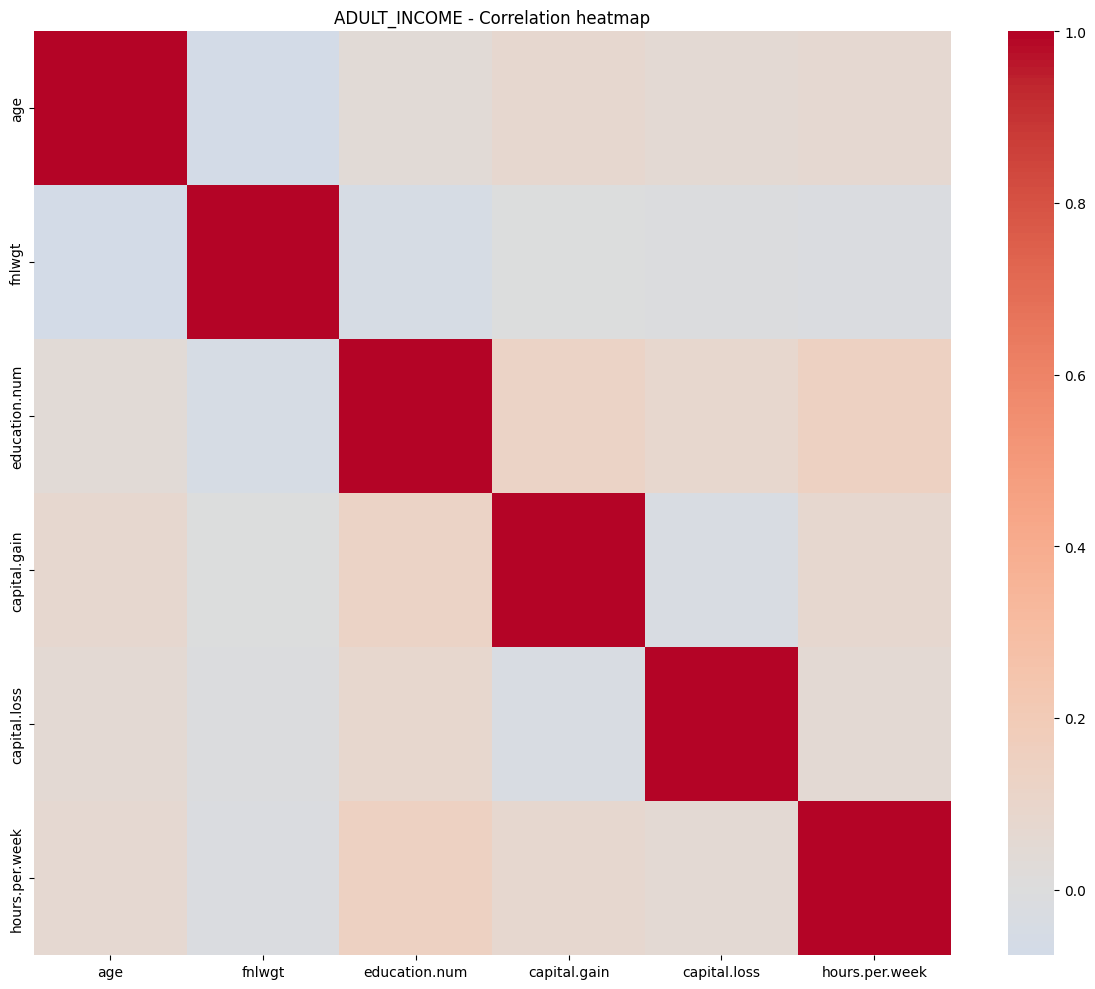

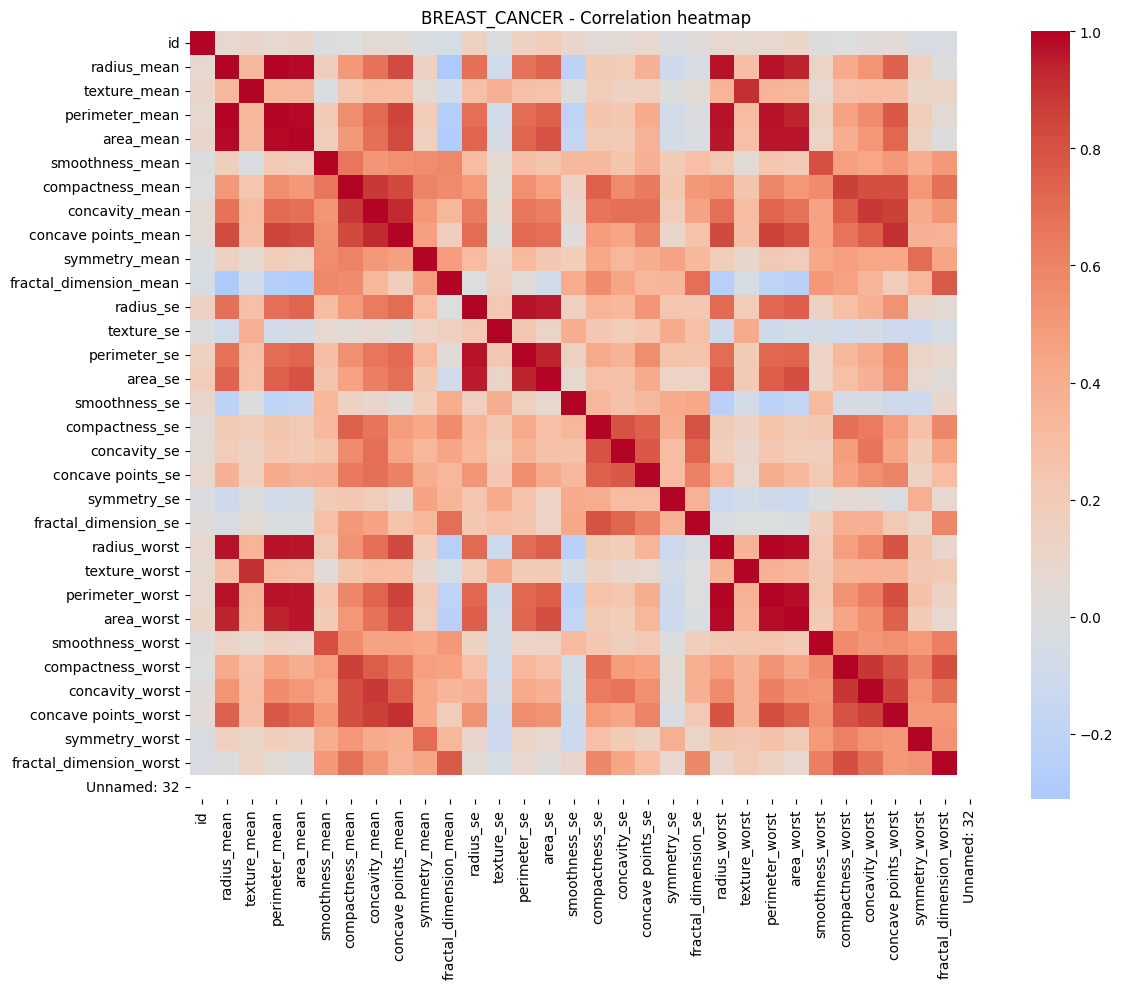

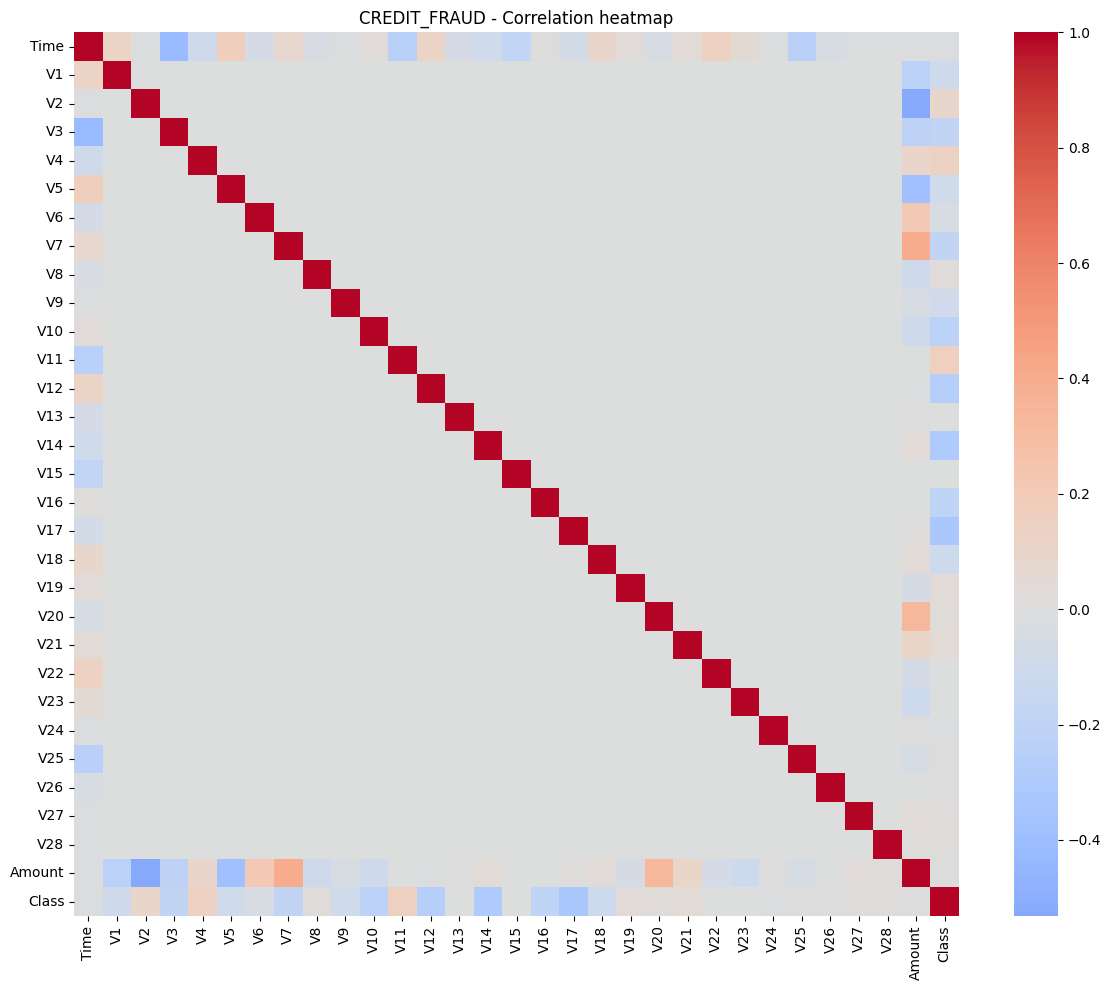

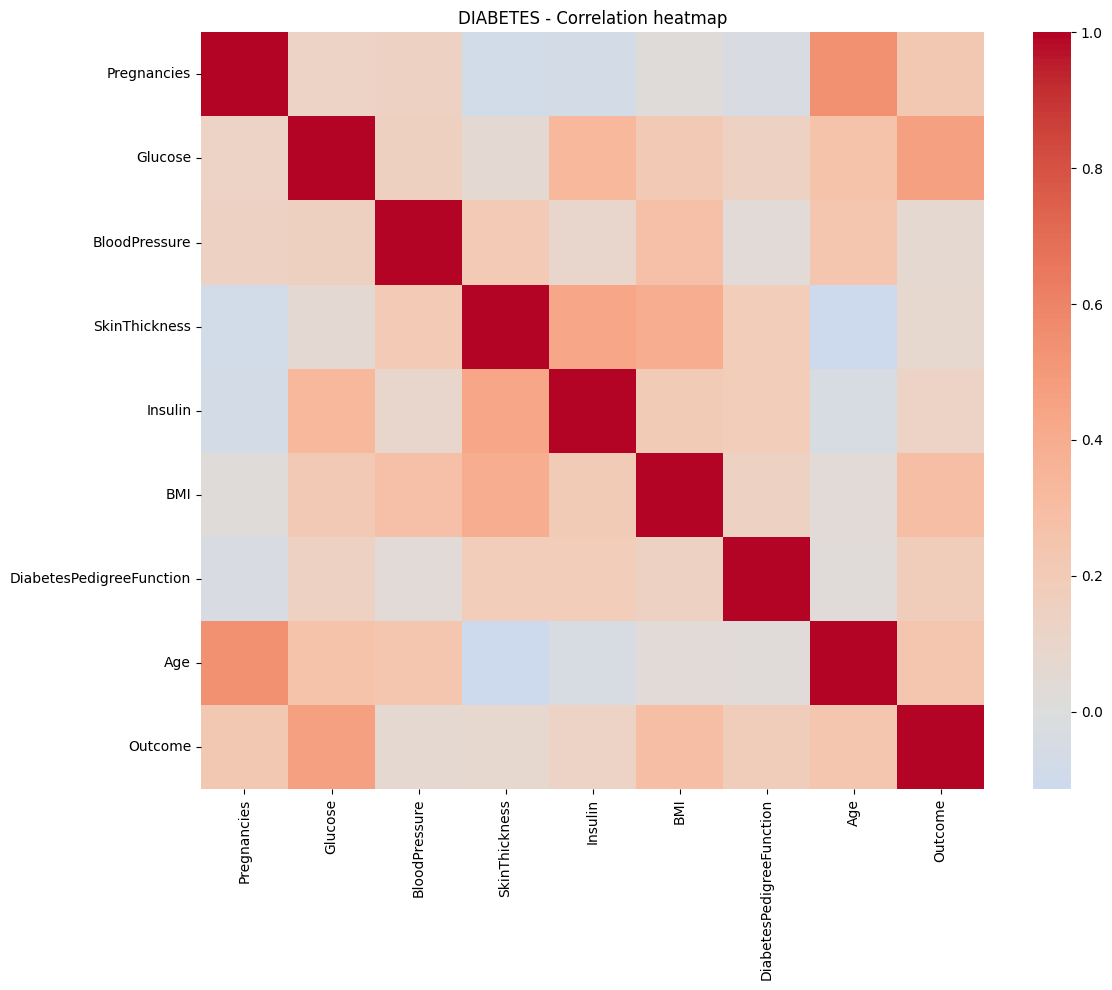

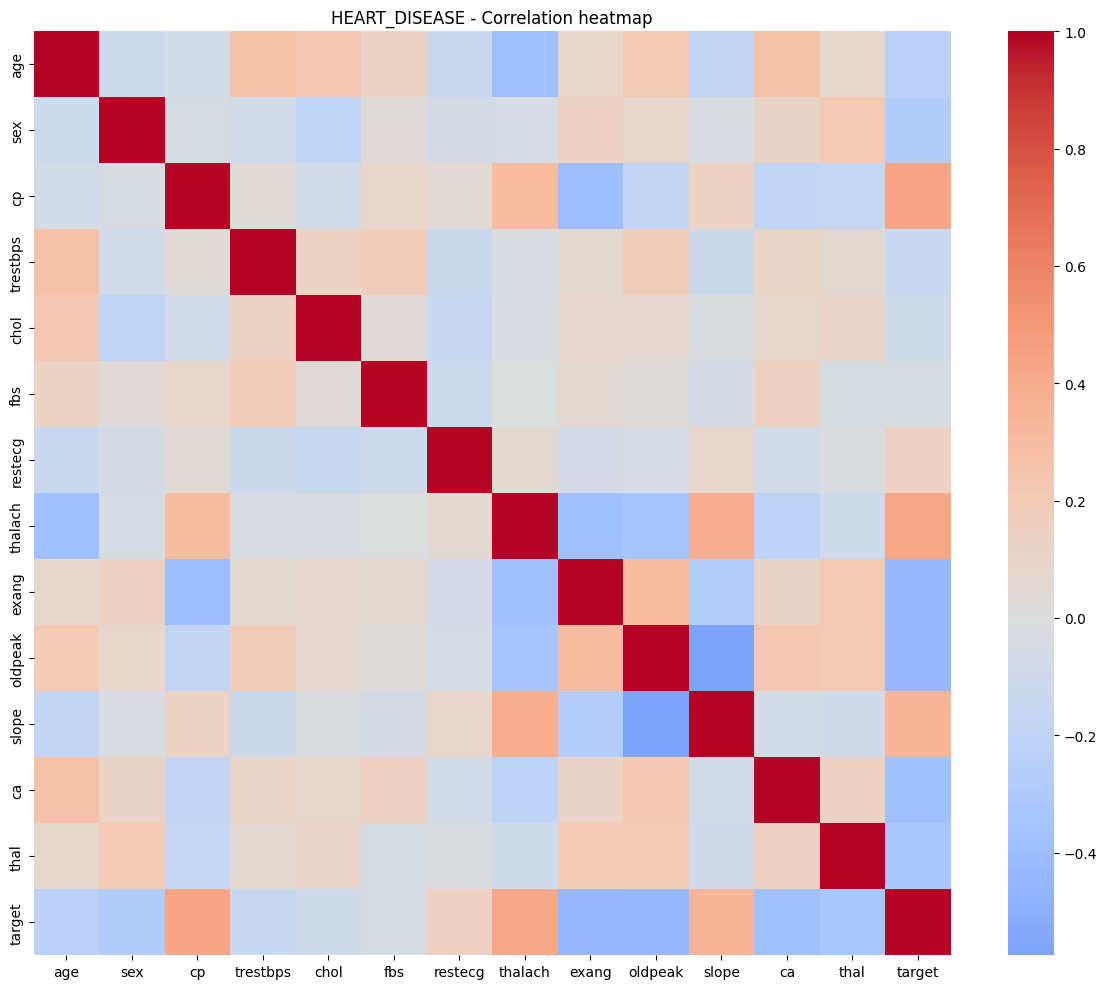

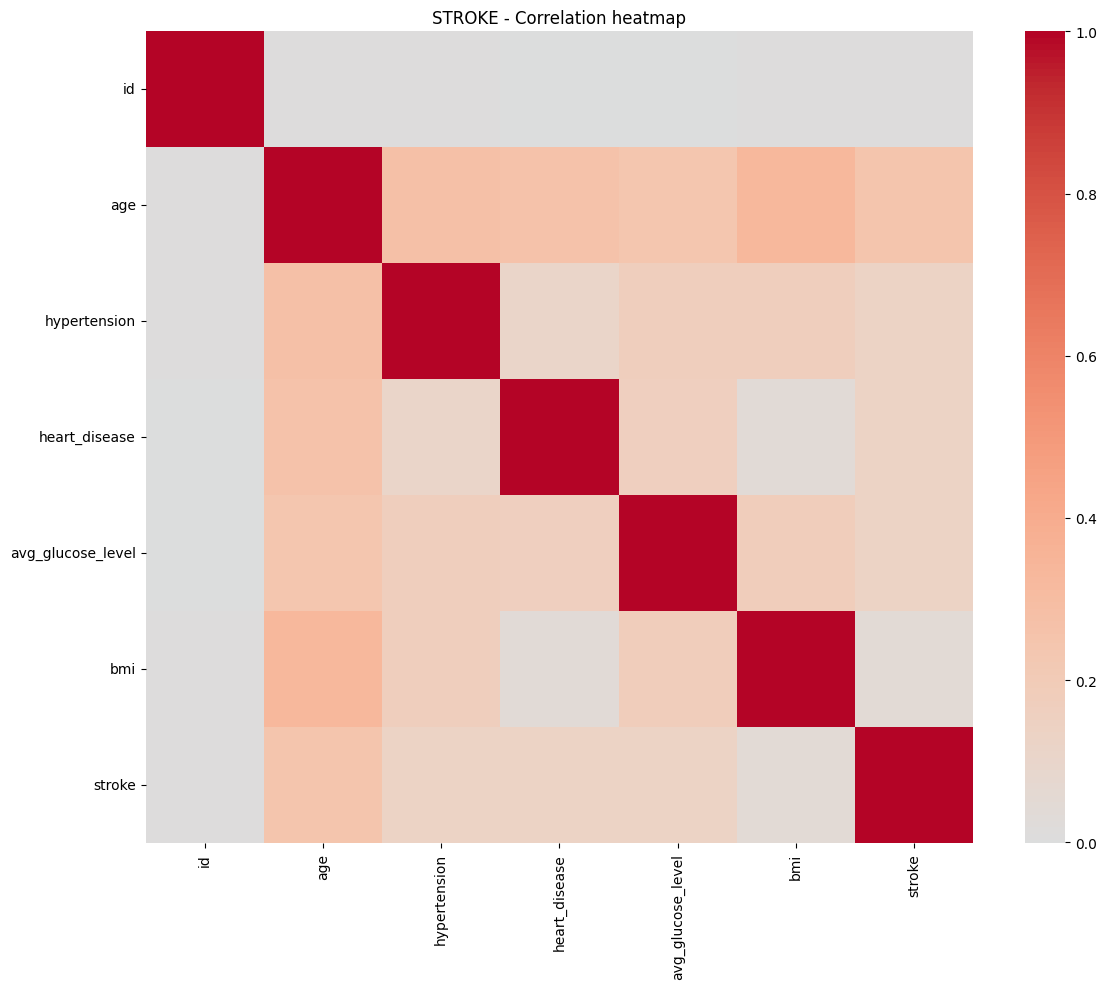

In [22]:
# heatmaps for correlation
for name , df in datasets.items():
    numerical_df = df.select_dtypes(include = [np.number])
    plt.figure(figsize = (12,10))
    sns.heatmap(numerical_df.corr() , cmap = 'coolwarm' , center = 0 ,annot = False)
    plt.title(f"{name.upper()} - Correlation heatmap")
    plt.tight_layout()
    plt.show()

In [23]:
for name, df in datasets.items():
    numerical_df = df.select_dtypes(include=[np.number])
    corr = numerical_df.corr().abs()
    
    #get pairs with correlation > 0.9 (excluding diagonal)
    high_corr = []
    cols = corr.columns
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            if corr.iloc[i,j] > 0.9:
                high_corr.append((cols[i], cols[j], round(corr.iloc[i,j], 3)))
    
    print(f"\n{name.upper()} - pairs with correlation > 0.9:")
    if high_corr:
        for pair in high_corr:
            print(f"  {pair[0]} vs {pair[1]}: {pair[2]}")
    else:
        print("  None")


ADULT_INCOME - Pairs with correlation > 0.9:
  None

BREAST_CANCER - Pairs with correlation > 0.9:
  radius_mean vs perimeter_mean: 0.998
  radius_mean vs area_mean: 0.987
  radius_mean vs radius_worst: 0.97
  radius_mean vs perimeter_worst: 0.965
  radius_mean vs area_worst: 0.941
  texture_mean vs texture_worst: 0.912
  perimeter_mean vs area_mean: 0.987
  perimeter_mean vs radius_worst: 0.969
  perimeter_mean vs perimeter_worst: 0.97
  perimeter_mean vs area_worst: 0.942
  area_mean vs radius_worst: 0.963
  area_mean vs perimeter_worst: 0.959
  area_mean vs area_worst: 0.959
  concavity_mean vs concave points_mean: 0.921
  concave points_mean vs concave points_worst: 0.91
  radius_se vs perimeter_se: 0.973
  radius_se vs area_se: 0.952
  perimeter_se vs area_se: 0.938
  radius_worst vs perimeter_worst: 0.994
  radius_worst vs area_worst: 0.984
  perimeter_worst vs area_worst: 0.978

CREDIT_FRAUD - Pairs with correlation > 0.9:
  None

DIABETES - Pairs with correlation > 0.9:
  None

# What I Found in the Data

Before building anything, I explored all six datasets to understand what I'm working with.
Here's what stood out.

---

## The Datasets at a Glance

Six binary classification problems, very different in size and complexity.
Credit Fraud is massive (284k rows), Heart Disease is tiny (1k rows).
Everything else sits in between.

---

## Stuff to Clean Up

**Breast Cancer** has two useless columns — `id` (just a patient number) and 
`Unnamed: 32` (completely empty, all 569 values are null). Both get dropped.

**Stroke** has an `id` column too. Same story, drop it.

---

## Missing Values

Only two datasets have real missing value problems:

**Stroke** — `bmi` is missing for 201 patients. Not random noise, 
that's 4% of the dataset. We'll impute with median.

**Diabetes** — No NaN values on paper, but Glucose, BloodPressure, 
SkinThickness, Insulin and BMI all have zeros which is biologically impossible. 
A blood pressure of 0 means the data is missing, not that the patient is dead. 
We'll replace zeros with NaN and then impute.

---

## Categorical Columns

**Stroke** has 5 — gender, ever_married, work_type, Residence_type, smoking_status

**Adult Income** has 8 — workclass, education, marital.status, occupation, 
relationship, race, sex, native.country

Everything else is already numerical.

---

## Class Imbalance — The Biggest Challenge

This is where things get interesting.

Heart Disease is perfectly balanced. Breast Cancer and Diabetes are fine.
But Credit Fraud has 0.17% fraud cases — meaning if the model just predicts
"not fraud" for everything, it gets 99.8% accuracy. That's useless.
Stroke has a similar problem at 5% positive cases.

For these two datasets, accuracy means nothing. 
We'll rely on F1, Precision, Recall and MCC instead.

---

## Multicollinearity

Only Breast Cancer has a problem here — 21 feature pairs with correlation above 0.9.
Makes sense because radius, perimeter and area are geometrically linked.
Our `remove_multicollinear_features` function handles this automatically.
Every other dataset is clean.

---

## Plan Going into Preprocessing

- **Breast Cancer** → drop 2 cols, remove correlated features
- **Credit Fraud** → scale Amount and Time, be careful with metrics
- **Heart Disease** → standard pipeline, nothing special
- **Diabetes** → replace impossible zeros, then impute
- **Stroke** → drop id, impute bmi, one-hot encode 5 cols
- **Adult Income** → one-hot encode 8 cols, largest encoding job

## Summary Table :

| Dataset       | Target    | Categorical | Missing Values | Imbalance  |
| ------------- | --------- | ----------- | -------------- | ---------- |
| Breast Cancer | diagnosis | none        | none           | balanced   |
| Credit Fraud  | Class     | none        | none           | extreme    |
| Heart Disease | target    | some        | none           | balanced   |
| Diabetes      | Outcome   | none        | fake zeros     | moderate   |
| Stroke        | stroke    | 5           | bmi            | imbalanced |
| Adult Income  | income    | 8           | some           | moderate   |
